Importing the libraries we'll be using for this project

In [278]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [279]:
#Setting the seaborn style for the charts
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

Importing the dataset for the analysis and prediction

In [280]:
df = pd.read_csv("../dataset/Telco Customer Churn.csv")

We'll start by viewing the first 5 columns

In [281]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [282]:
df.shape

(7043, 21)

In [283]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [284]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Observation
From the dataset above, we have2

In [285]:
df['gender'].unique()

array(['Female', 'Male'], dtype=object)

In [286]:
df['gender'].head()

0    Female
1      Male
2      Male
3      Male
4    Female
Name: gender, dtype: object

In [287]:
df['customerID'].unique()

array(['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', ..., '4801-JZAZL',
       '8361-LTMKD', '3186-AJIEK'], shape=(7043,), dtype=object)

I will be dropping the customerID column due to the high number of unique values and it does not carry any predictive signal

In [288]:
df = df.drop('customerID', axis=1)

In [289]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [290]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


# 1. Question: What is the percentage of customers that leave?

In [291]:
df.Churn.value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

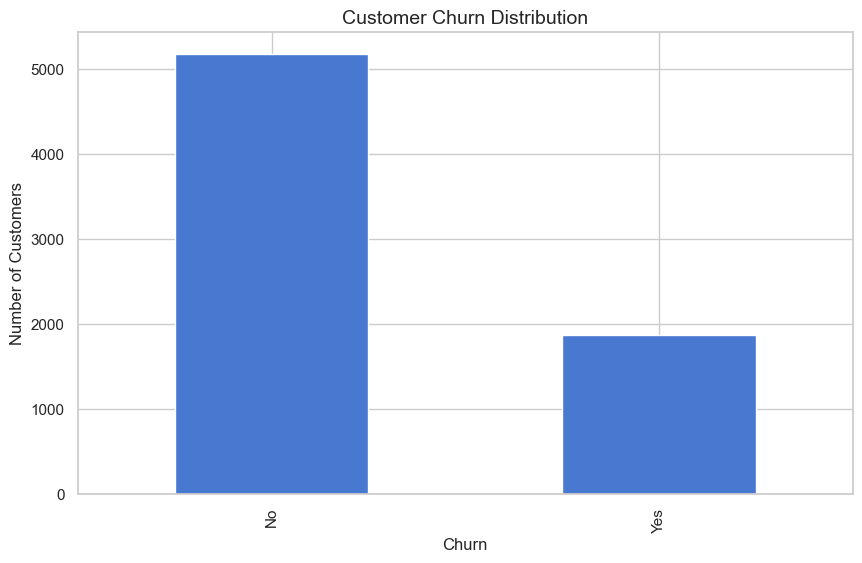

In [292]:
df['Churn'].value_counts().plot(kind='bar')
plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

## Observation from the chart above
### We have over 5000 customers that stay and almost 2000 that leaves the company
### That is 26.5% of customers stop using the services over time

# 2. Question: Do contract type affect Customer churn?

In [293]:
df.Contract.value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

### Due to the imbalanced distribution of this column. I will be normalizing the column

In [294]:
#Normalizing the column
contract_churn_rate = pd.crosstab(df['Contract'], df['Churn'], normalize='index')
print(contract_churn_rate)

Churn                 No       Yes
Contract                          
Month-to-month  0.572903  0.427097
One year        0.887305  0.112695
Two year        0.971681  0.028319


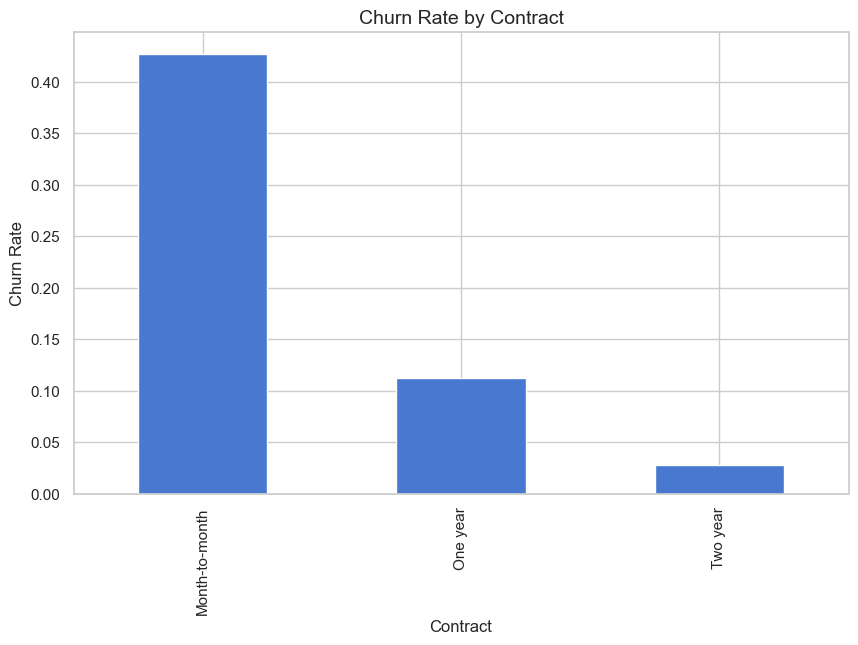

In [295]:
contract_churn_rate['Yes'].plot(kind='bar')

plt.title('Churn Rate by Contract')
plt.ylabel('Churn Rate')
plt.show()

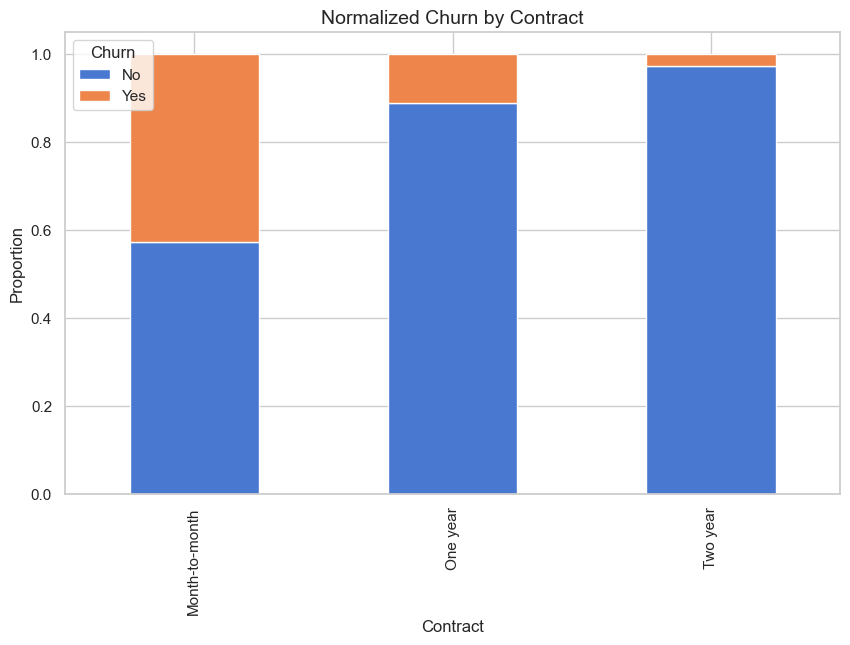

In [296]:
contract_churn_rate.plot(kind='bar', stacked=True)
plt.ylabel('Proportion')
plt.title('Normalized Churn by Contract')
plt.show()


## Observation from the charts above,
### The contract with the highest churn rate is the "month-to-month" contract, followed by the the "One year"contracts. Customers with "Two year" contracts barely leave the company.
### So it is safe to say that customers with shorter contracts have a higher chance of leaving 

# 3. Question: Do Customer age category affect churn rate?

In [297]:
df.SeniorCitizen.value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

### Due to the imbalanced distribution of this column. I will be normalizing the column

In [298]:
#Normalizing the column
seniorCitizen_churn_rate = pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index')
print(seniorCitizen_churn_rate)

Churn                No       Yes
SeniorCitizen                    
0              0.763938  0.236062
1              0.583187  0.416813


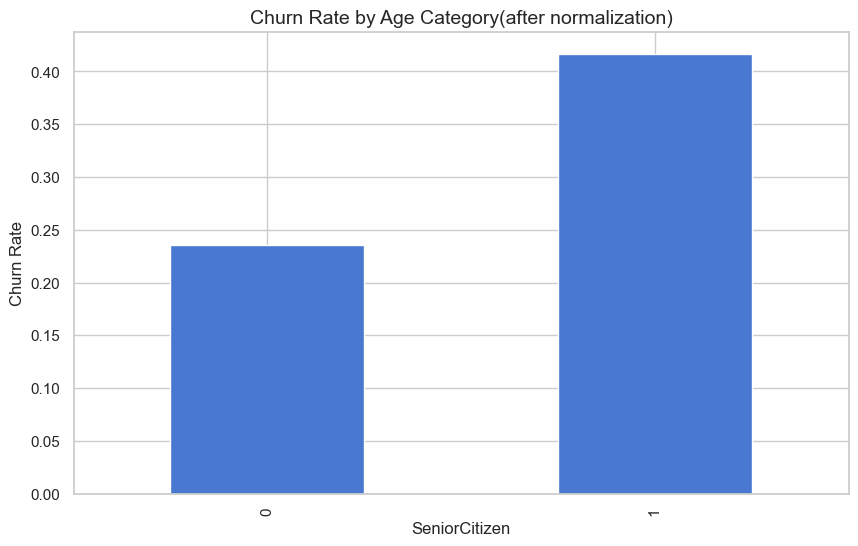

In [299]:
seniorCitizen_churn_rate['Yes'].plot(kind='bar')

plt.title('Churn Rate by Age Category(after normalization)')
plt.ylabel('Churn Rate')
plt.show()

## Observation from the charts above
### Senior citizens stop using the services the most. They have a higher churn rate

# 4. Question: What services are prone to churning?

In [300]:
df.InternetService.value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

### Due to the imbalance in the columns, I will be normalizing the column

In [301]:
#Normalizing the column
internet_churn_rate = pd.crosstab(df['InternetService'], df['Churn'], normalize='index')

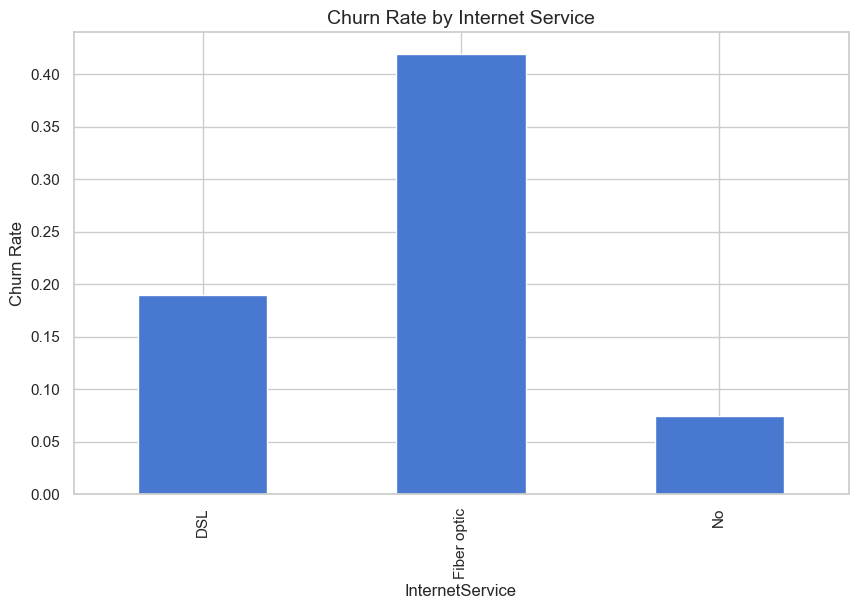

In [302]:
internet_churn_rate['Yes'].plot(kind='bar')

plt.title('Churn Rate by Internet Service')
plt.ylabel('Churn Rate')
plt.show()

### From this chart above, Customers with the Fiber optics internet service have the highest churn rate compared to the others

## Getting insights from the Mobile service column

In [303]:
df['PhoneService'].value_counts()

PhoneService
Yes    6361
No      682
Name: count, dtype: int64

### Normalizing the colum due to the imbalance in data

In [304]:
phone_churn_rate = pd.crosstab(df['PhoneService'], df['Churn'], normalize='index')
#print(phone_churn_rate)


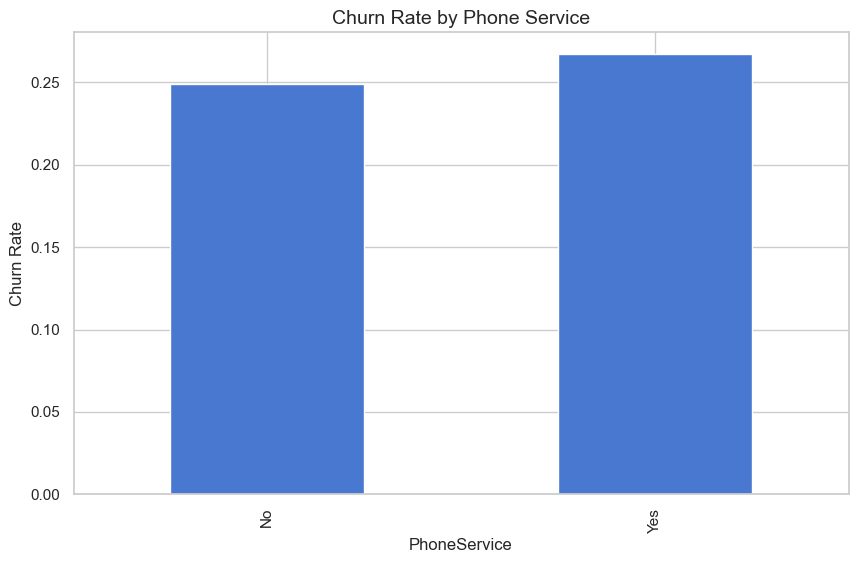

In [305]:
phone_churn_rate['Yes'].plot(kind='bar')

plt.title('Churn Rate by Phone Service')
plt.ylabel('Churn Rate')
plt.show()

### From the chart above, we can observe that customers with phone service have a higher churn rate compared to those without

### Now the next thing to check for is what combination of services have the highest churn rate

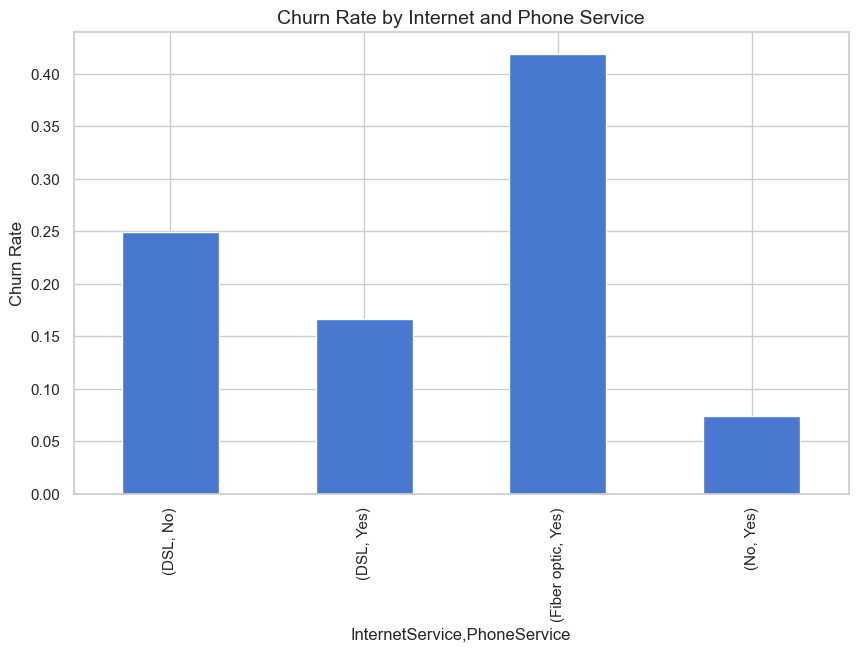

In [306]:
#Creating a pivot between the Internet and mobile service to see the services with the highest churn rate
pivot = pd.crosstab(
    [df['InternetService'], df['PhoneService']],
    df['Churn'],
    normalize='index'
)

#print(pivot)

pivot['Yes'].plot(kind='bar')

plt.title('Churn Rate by Internet and Phone Service')
plt.ylabel('Churn Rate')
plt.show()

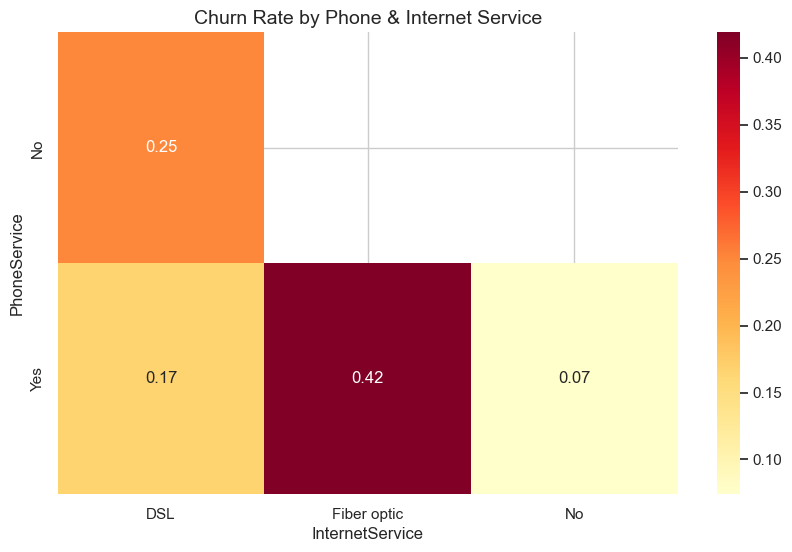

In [307]:
sns.heatmap(pd.crosstab(df['PhoneService'], df['InternetService'], 
                        values=df['Churn']=='Yes', aggfunc='mean'), 
            annot=True, fmt=".2f", cmap="YlOrRd")
plt.title('Churn Rate by Phone & Internet Service')
plt.show()

### The question was what services were prone to churning, and from the charts above, We can see that:
#### Phone services: Customers with Phone services have the highest churn rate
#### Internet services: Customers with the fiber optics have the highest churn rate

### and Customers with both fiber optics and a phone service are more likely to leave the company


# 5. Question: How do dependents affect customer churn?

In [308]:
df.Dependents.value_counts()

Dependents
No     4933
Yes    2110
Name: count, dtype: int64

In [309]:
dependents_churn_rate = pd.crosstab(df['Dependents'], df['Churn'], normalize='index')
print(dependents_churn_rate)


Churn             No       Yes
Dependents                    
No          0.687209  0.312791
Yes         0.845498  0.154502


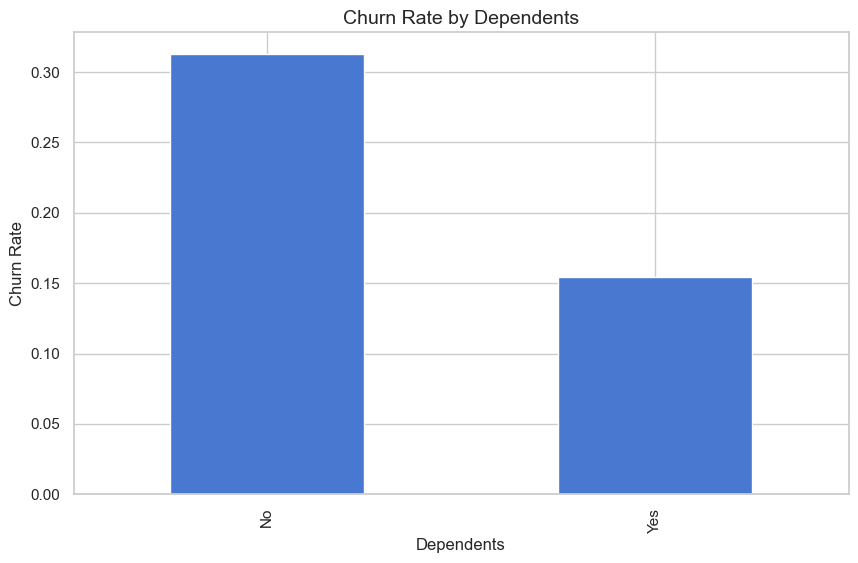

In [310]:
dependents_churn_rate['Yes'].plot(kind='bar')

plt.title('Churn Rate by Dependents')
plt.ylabel('Churn Rate')
plt.show()

### From the chart above, we see that customers without dependents have a higher churn rate compared to those with dependents

# 6. Question: What Tenures/Tenure range is prone to churning

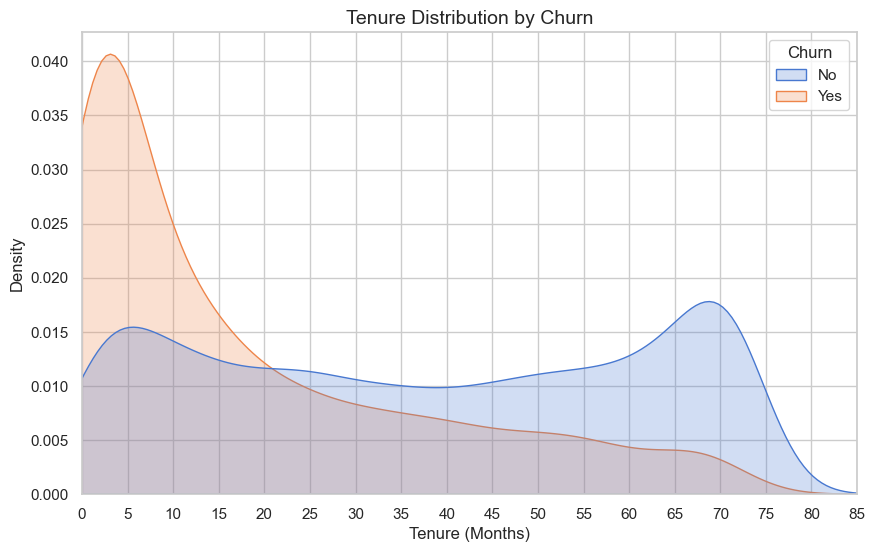

In [311]:
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, common_norm=False)
plt.xticks(np.arange(0, 86, 5))
plt.xlim(0,85)
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (Months)')
plt.show()

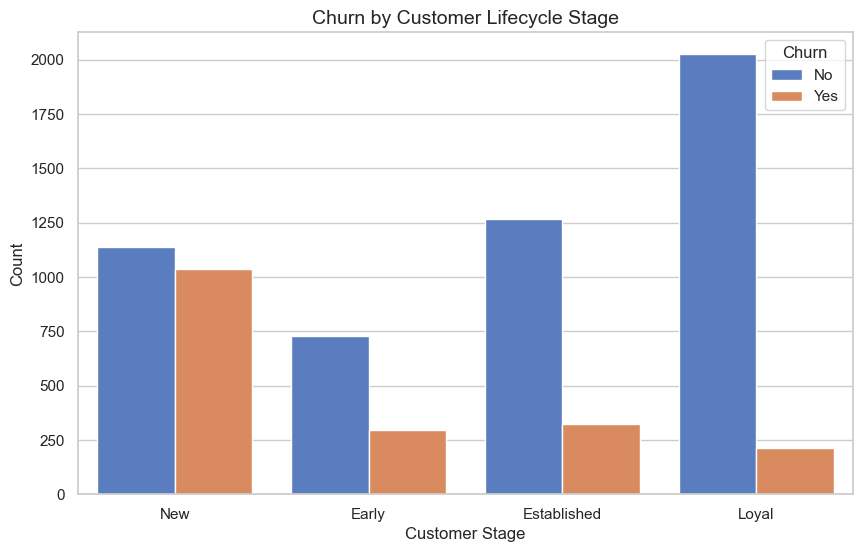

In [312]:
bins = [0, 12, 24, 48, 85]
#0 tenures are likely new customers
labels = ['New', 'Early', 'Established', 'Loyal']

df['customer_stage'] = pd.cut(df['tenure'], bins=bins, labels=labels)


sns.countplot(data=df, x='customer_stage', hue='Churn')

plt.title('Churn by Customer Lifecycle Stage')
plt.xlabel('Customer Stage')
plt.ylabel('Count')
plt.show()


### Observation from the charts above shows that New customers(0-12 months) have the highest churn rate. The churn rate reduces as the the tenure increases

## Question 7: Getting all the insights from the Charges

In [313]:
df.MonthlyCharges.max()

np.float64(118.75)

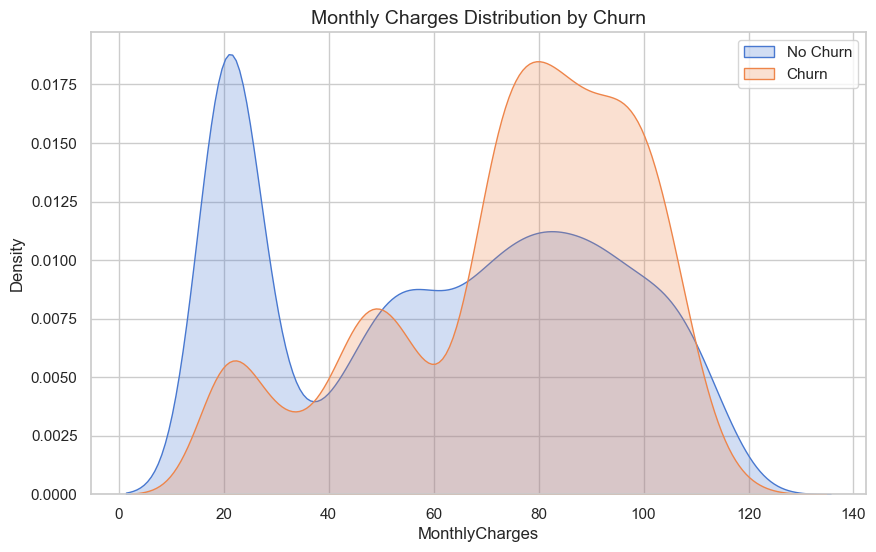

In [314]:
plt.figure(figsize=(10,6))

sns.kdeplot(data=df[df['Churn']=='No'], x='MonthlyCharges', fill=True, label='No Churn')
sns.kdeplot(data=df[df['Churn']=='Yes'], x='MonthlyCharges', fill=True, label='Churn')

plt.title("Monthly Charges Distribution by Churn")
plt.legend()
plt.show()

/var/folders/_r/k3gpjvns03v5rk0589lkgzg80000gn/T/ipykernel_2870/504266419.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate = df.groupby('ChargeGroup')['Churn'].value_counts(normalize=True).unstack()


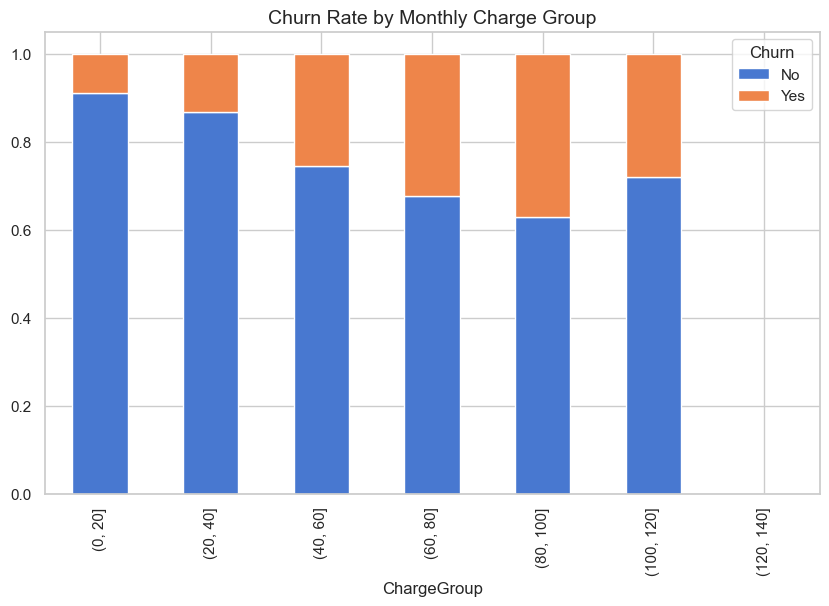

In [315]:
# Binning
df['ChargeGroup'] = pd.cut(df['MonthlyCharges'], bins=[0,20,40,60,80, 100, 120, 140])

churn_rate = df.groupby('ChargeGroup')['Churn'].value_counts(normalize=True).unstack()

churn_rate.plot(kind='bar', stacked=True)
plt.title('Churn Rate by Monthly Charge Group')
plt.show()

### From the chart above, the high risk customers are customers with monthly charges ranging from $(60-100)

### While customers with the lowest churn rate are customers with monthly charges ranging from $(20 - 40)

### Customers with higher monthly charges are prone to churning

## i. Total Charges

In [316]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   gender            7043 non-null   object  
 1   SeniorCitizen     7043 non-null   int64   
 2   Partner           7043 non-null   object  
 3   Dependents        7043 non-null   object  
 4   tenure            7043 non-null   int64   
 5   PhoneService      7043 non-null   object  
 6   MultipleLines     7043 non-null   object  
 7   InternetService   7043 non-null   object  
 8   OnlineSecurity    7043 non-null   object  
 9   OnlineBackup      7043 non-null   object  
 10  DeviceProtection  7043 non-null   object  
 11  TechSupport       7043 non-null   object  
 12  StreamingTV       7043 non-null   object  
 13  StreamingMovies   7043 non-null   object  
 14  Contract          7043 non-null   object  
 15  PaperlessBilling  7043 non-null   object  
 16  PaymentMethod     7043 n

### From the info above, we can see that the total object is of object type. So best way to proceed would be to convert it to a numeric column

In [317]:
#df['TotalCharges'] = df['TotalCharges'].astype(float)

### While trying to convert the TotalCharges column to float, noticed that there were empty strings and those were customers with 0 tenures

In [318]:
#Assigning the value of 0 to the Total charges column that hae customers with 0 tenure
df.loc[df['tenure'] == 0, 'TotalCharges'] = 0

In [319]:
#Converting the TotalCharges column to float
df['TotalCharges'] = df['TotalCharges'].astype(float)

In [320]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   gender            7043 non-null   object  
 1   SeniorCitizen     7043 non-null   int64   
 2   Partner           7043 non-null   object  
 3   Dependents        7043 non-null   object  
 4   tenure            7043 non-null   int64   
 5   PhoneService      7043 non-null   object  
 6   MultipleLines     7043 non-null   object  
 7   InternetService   7043 non-null   object  
 8   OnlineSecurity    7043 non-null   object  
 9   OnlineBackup      7043 non-null   object  
 10  DeviceProtection  7043 non-null   object  
 11  TechSupport       7043 non-null   object  
 12  StreamingTV       7043 non-null   object  
 13  StreamingMovies   7043 non-null   object  
 14  Contract          7043 non-null   object  
 15  PaperlessBilling  7043 non-null   object  
 16  PaymentMethod     7043 n

In [321]:
df.TotalCharges.max()
#df.TotalCharges.min()

np.float64(8684.8)

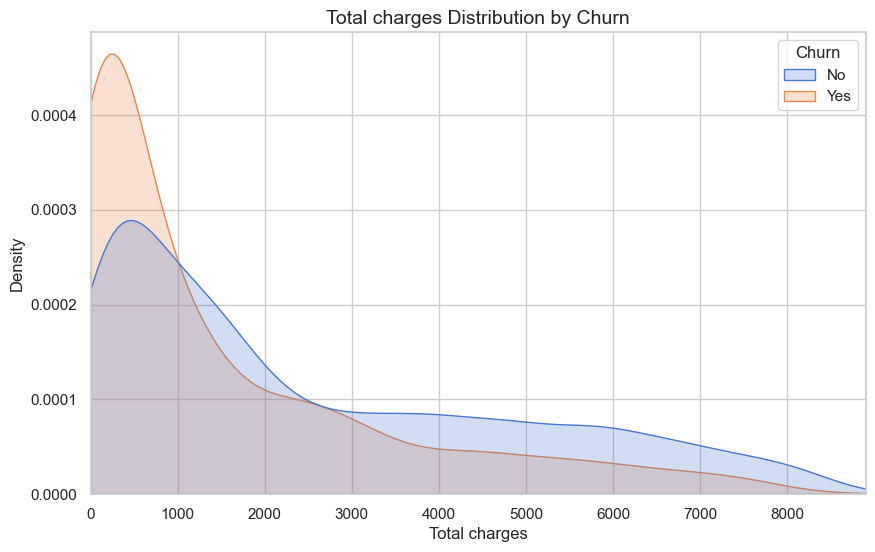

In [322]:
sns.kdeplot(data=df, x='TotalCharges', hue='Churn', fill=True, common_norm=False)
plt.xticks(np.arange(0, 8900, 1000))
plt.xlim(0,8900)
plt.title('Total charges Distribution by Churn')
plt.xlabel('Total charges')
plt.show()

/var/folders/_r/k3gpjvns03v5rk0589lkgzg80000gn/T/ipykernel_2870/1085708387.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate = df.groupby('TChargeGroup')['Churn'].value_counts(normalize=True).unstack()


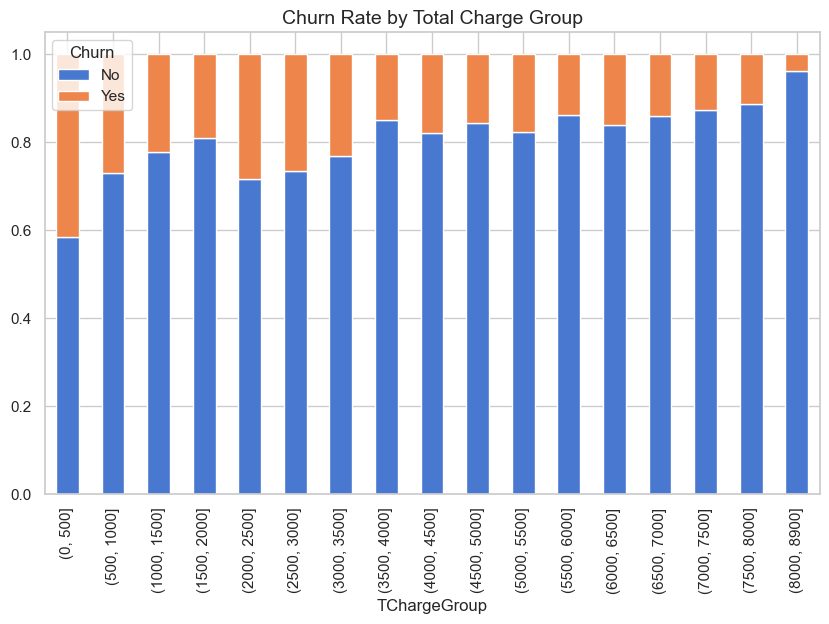

In [323]:
# Binning
df['TChargeGroup'] = pd.cut(df['TotalCharges'], bins=[0,500,1000,1500,2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000, 7500, 8000, 8900])

churn_rate = df.groupby('TChargeGroup')['Churn'].value_counts(normalize=True).unstack()

churn_rate.plot(kind='bar', stacked=True)
plt.title('Churn Rate by Total Charge Group')
plt.show()

## From the charts above, We can see that Customers with the highest churn rate have a total charge ranging from $(0-500). Safe to say that the high risk customers are customers with low total charges.

# Comparing the charges to tenure and contract to understand customer behavior better

### I am having a hard time doing this at the moment. I will improve on this note

# Final EDA Summary

## High Risk Customers:
    1. Month to Month Contract Customers
    2. Senior citizens
    3. Customers with a Fiber optic internet service, Customers with a mobile service, and customers with both of them
    4. New customers (Customers with tenures from 0- 12 months)
    5. Customers with high monthly charges ($60 - $120)

## Observation:
    there is still more to be done here. will update the notebook
    

# Convert Object columns to Numeric columns

In [324]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   gender            7043 non-null   object  
 1   SeniorCitizen     7043 non-null   int64   
 2   Partner           7043 non-null   object  
 3   Dependents        7043 non-null   object  
 4   tenure            7043 non-null   int64   
 5   PhoneService      7043 non-null   object  
 6   MultipleLines     7043 non-null   object  
 7   InternetService   7043 non-null   object  
 8   OnlineSecurity    7043 non-null   object  
 9   OnlineBackup      7043 non-null   object  
 10  DeviceProtection  7043 non-null   object  
 11  TechSupport       7043 non-null   object  
 12  StreamingTV       7043 non-null   object  
 13  StreamingMovies   7043 non-null   object  
 14  Contract          7043 non-null   object  
 15  PaperlessBilling  7043 non-null   object  
 16  PaymentMethod     7043 n

In [325]:
#Importing the Libraries I will be using for this
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

## Converting all the columns without an inherent order using the Label encoder

In [326]:
#Gender
encoder = LabelEncoder()
encoded_data = encoder.fit_transform(df['gender'])
df['gender'] = encoded_data

In [327]:
#MultipleLines
encoder = LabelEncoder()
encoded_data = encoder.fit_transform(df['MultipleLines'])
df['MultipleLines'] = encoded_data

In [328]:
#Internet Service
encoder = LabelEncoder()
encoded_data = encoder.fit_transform(df['InternetService'])
df['InternetService'] = encoded_data

In [329]:
df.InternetService.value_counts()

InternetService
1    3096
0    2421
2    1526
Name: count, dtype: int64

In [330]:
#Contract
encoder = LabelEncoder()
encoded_data = encoder.fit_transform(df['Contract'])
df['Contract'] = encoded_data

In [331]:
df.Contract.value_counts()

Contract
0    3875
2    1695
1    1473
Name: count, dtype: int64

In [332]:
#Payment Method
encoder = LabelEncoder()
encoded_data = encoder.fit_transform(df['PaymentMethod'])
df['PaymentMethod'] = encoded_data

## Converting columns with an order using the Ordinal Encoder

In [333]:
#Partner
encoder = OrdinalEncoder(categories=[['No', 'Yes']])
df['Partner']= encoder.fit_transform(df[['Partner']])


In [334]:
#PhoneService
encoder = OrdinalEncoder(categories=[['No', 'Yes']])
df['PhoneService']= encoder.fit_transform(df[['PhoneService']])


In [335]:
#Dependents
encoder = OrdinalEncoder(categories=[['No', 'Yes']])
df['Dependents'] = encoder.fit_transform(df[['Dependents']])

In [336]:
#OnlineSecurity
encoder = OrdinalEncoder(categories=[['No internet service', 'No', 'Yes']])
df.OnlineSecurity = encoder.fit_transform(df[['OnlineSecurity']])
                         

In [337]:
#OnlineBackup
encoder = OrdinalEncoder(categories=[['No internet service', 'No', 'Yes']])
df.OnlineBackup = encoder.fit_transform(df[['OnlineBackup']])

In [338]:
#DeviceProtection
encoder = OrdinalEncoder(categories=[['No internet service', 'No', 'Yes']])
df.DeviceProtection = encoder.fit_transform(df[['DeviceProtection']])

In [339]:
#TechSupport
encoder = OrdinalEncoder(categories=[['No internet service', 'No', 'Yes']])
df.TechSupport = encoder.fit_transform(df[['TechSupport']])

In [340]:
#Streaming TV
encoder = OrdinalEncoder(categories=[['No internet service', 'No', 'Yes']])
df.StreamingTV = encoder.fit_transform(df[['StreamingTV']])

In [341]:
#Streaming Movies
encoder = OrdinalEncoder(categories=[['No internet service', 'No', 'Yes']])
df.StreamingMovies = encoder.fit_transform(df[['StreamingMovies']])

In [342]:
#Paperless Billing
encoder = OrdinalEncoder(categories=[['No', 'Yes']])
df['PaperlessBilling'] = encoder.fit_transform(df[['PaperlessBilling']])

In [343]:
#Churn
encoder = OrdinalEncoder(categories=[['No', 'Yes']])
df['Churn'] = encoder.fit_transform(df[['Churn']])

In [344]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   gender            7043 non-null   int64   
 1   SeniorCitizen     7043 non-null   int64   
 2   Partner           7043 non-null   float64 
 3   Dependents        7043 non-null   float64 
 4   tenure            7043 non-null   int64   
 5   PhoneService      7043 non-null   float64 
 6   MultipleLines     7043 non-null   int64   
 7   InternetService   7043 non-null   int64   
 8   OnlineSecurity    7043 non-null   float64 
 9   OnlineBackup      7043 non-null   float64 
 10  DeviceProtection  7043 non-null   float64 
 11  TechSupport       7043 non-null   float64 
 12  StreamingTV       7043 non-null   float64 
 13  StreamingMovies   7043 non-null   float64 
 14  Contract          7043 non-null   int64   
 15  PaperlessBilling  7043 non-null   float64 
 16  PaymentMethod     7043 n

### Checking for Outliers

In [345]:
df.describe()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.504756,0.162147,0.483033,0.299588,32.371149,0.903166,0.940508,0.872923,1.069999,1.128212,1.127219,1.073548,1.167684,1.171234,0.690473,0.592219,1.574329,64.761692,2279.734304,0.265370
std,0.500013,0.368612,0.499748,0.458110,24.559481,0.295752,0.948554,0.737796,0.706051,0.738369,0.737868,0.708201,0.756958,0.758507,0.833755,0.491457,1.068104,30.090047,2266.794470,0.441561
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,35.500000,398.550000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,2.000000,70.350000,1394.550000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,89.850000,3786.600000,1.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,3.000000,118.750000,8684.800000,1.000000


### From my observation, there don't seem to be any outlier here

## Checking for Multicolinearity Using a Correlation Heatmap

In [346]:
del df['customer_stage']
del df['ChargeGroup']
del df['TChargeGroup']

<Axes: >

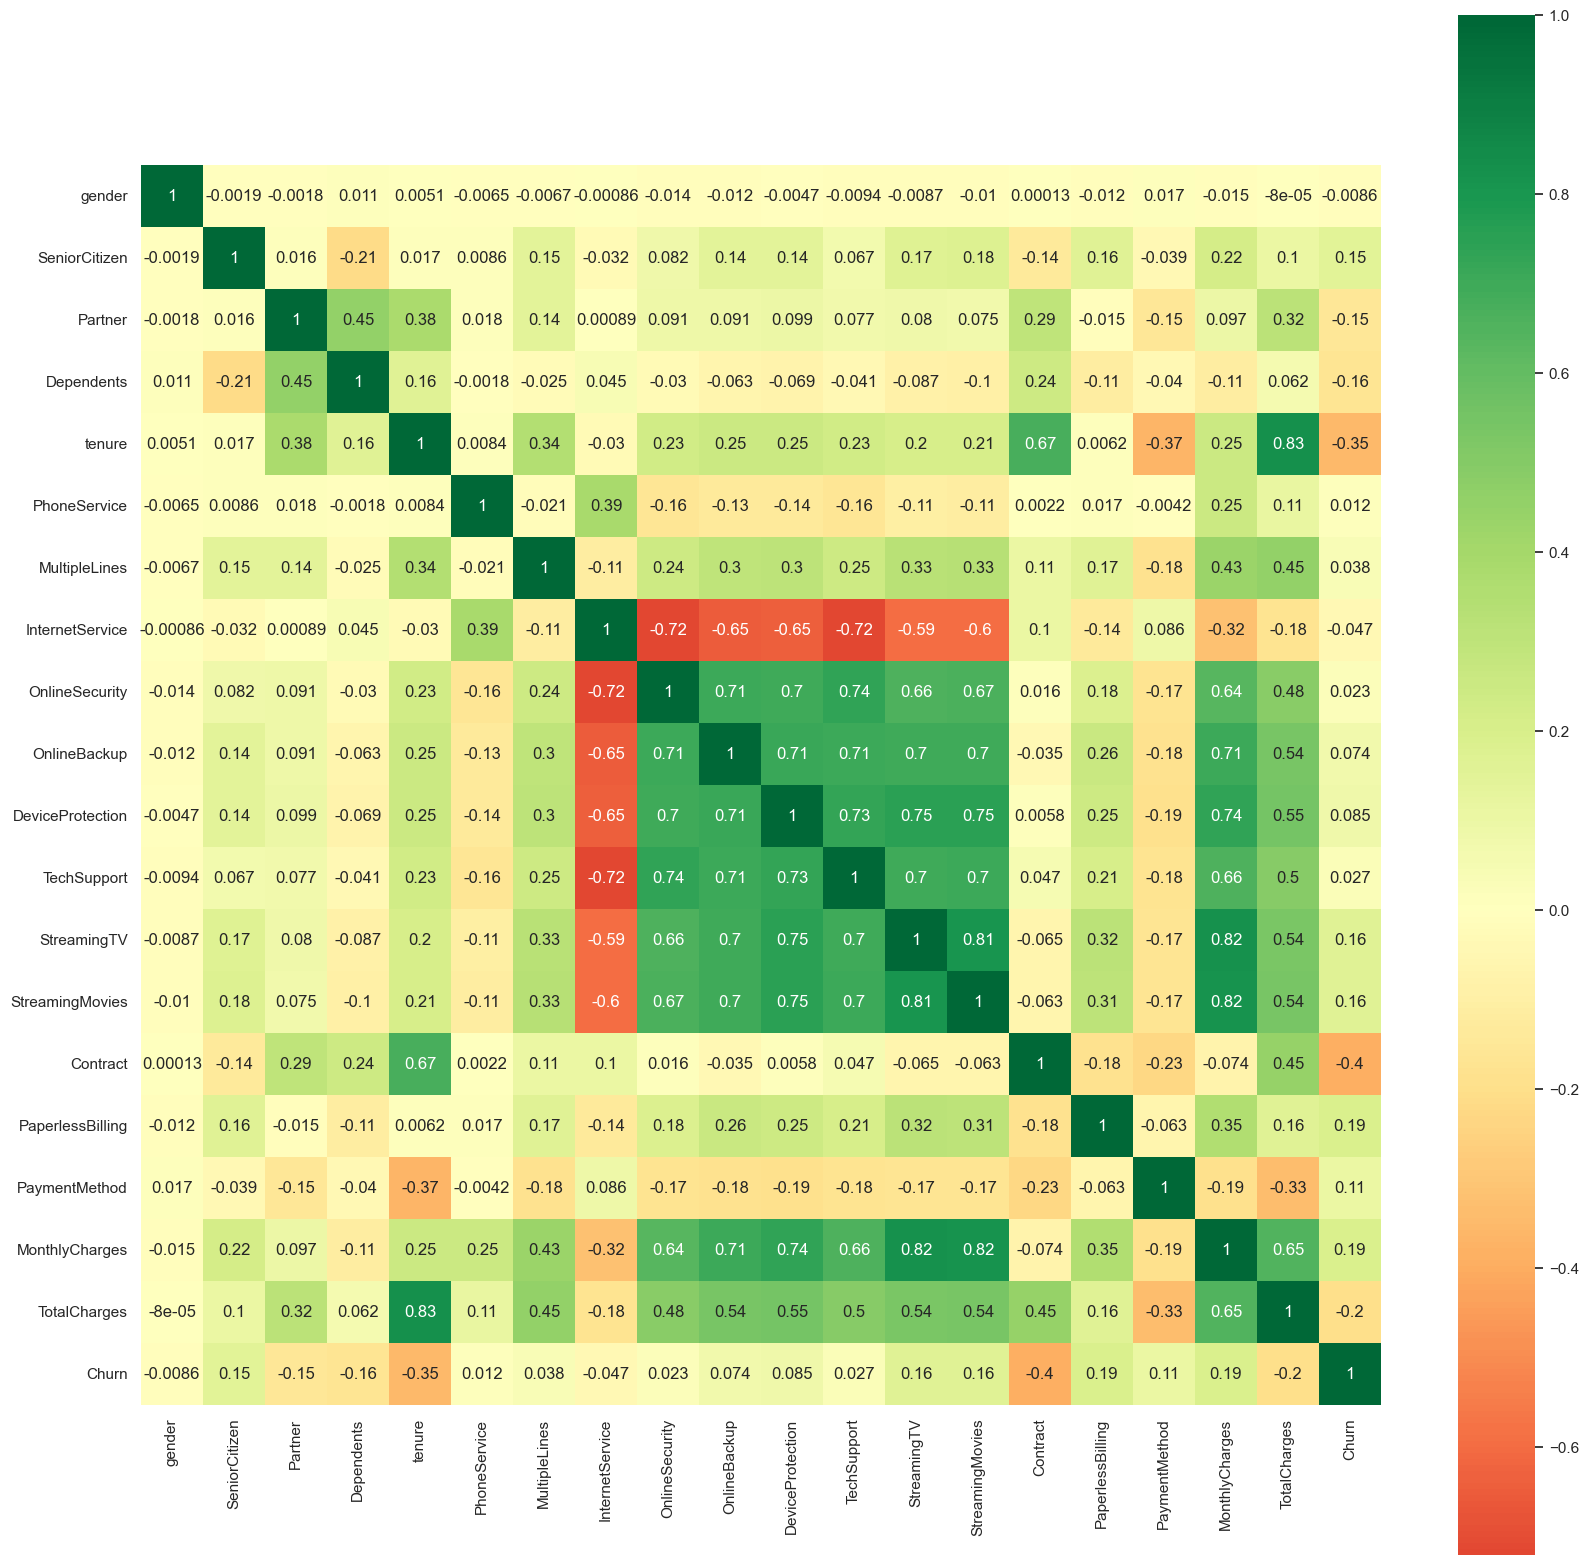

In [347]:
plt.figure(figsize = (20, 20))
# Plot the correlation matrix as a heatmap
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', center=0, square=True)

## Observation from the correlation heatmap
1. StreamingTV and StreamingMovies are multicolinear(Combine them to get a single column)
2. Gender have the least correlation with all the variables(will drop the column)
3. Both StreamingTV and StreamingMovies are multicolinear to MonthlyCharges
4. Tenure and TotalCharges are multicolinear()

In [348]:
#1
services = ['StreamingTV','StreamingMovies']

df['StreamingServices'] = df[services].sum(axis=1)

del df['StreamingMovies']
del df['StreamingTV']


In [349]:
#2
del df['gender']

<Axes: >

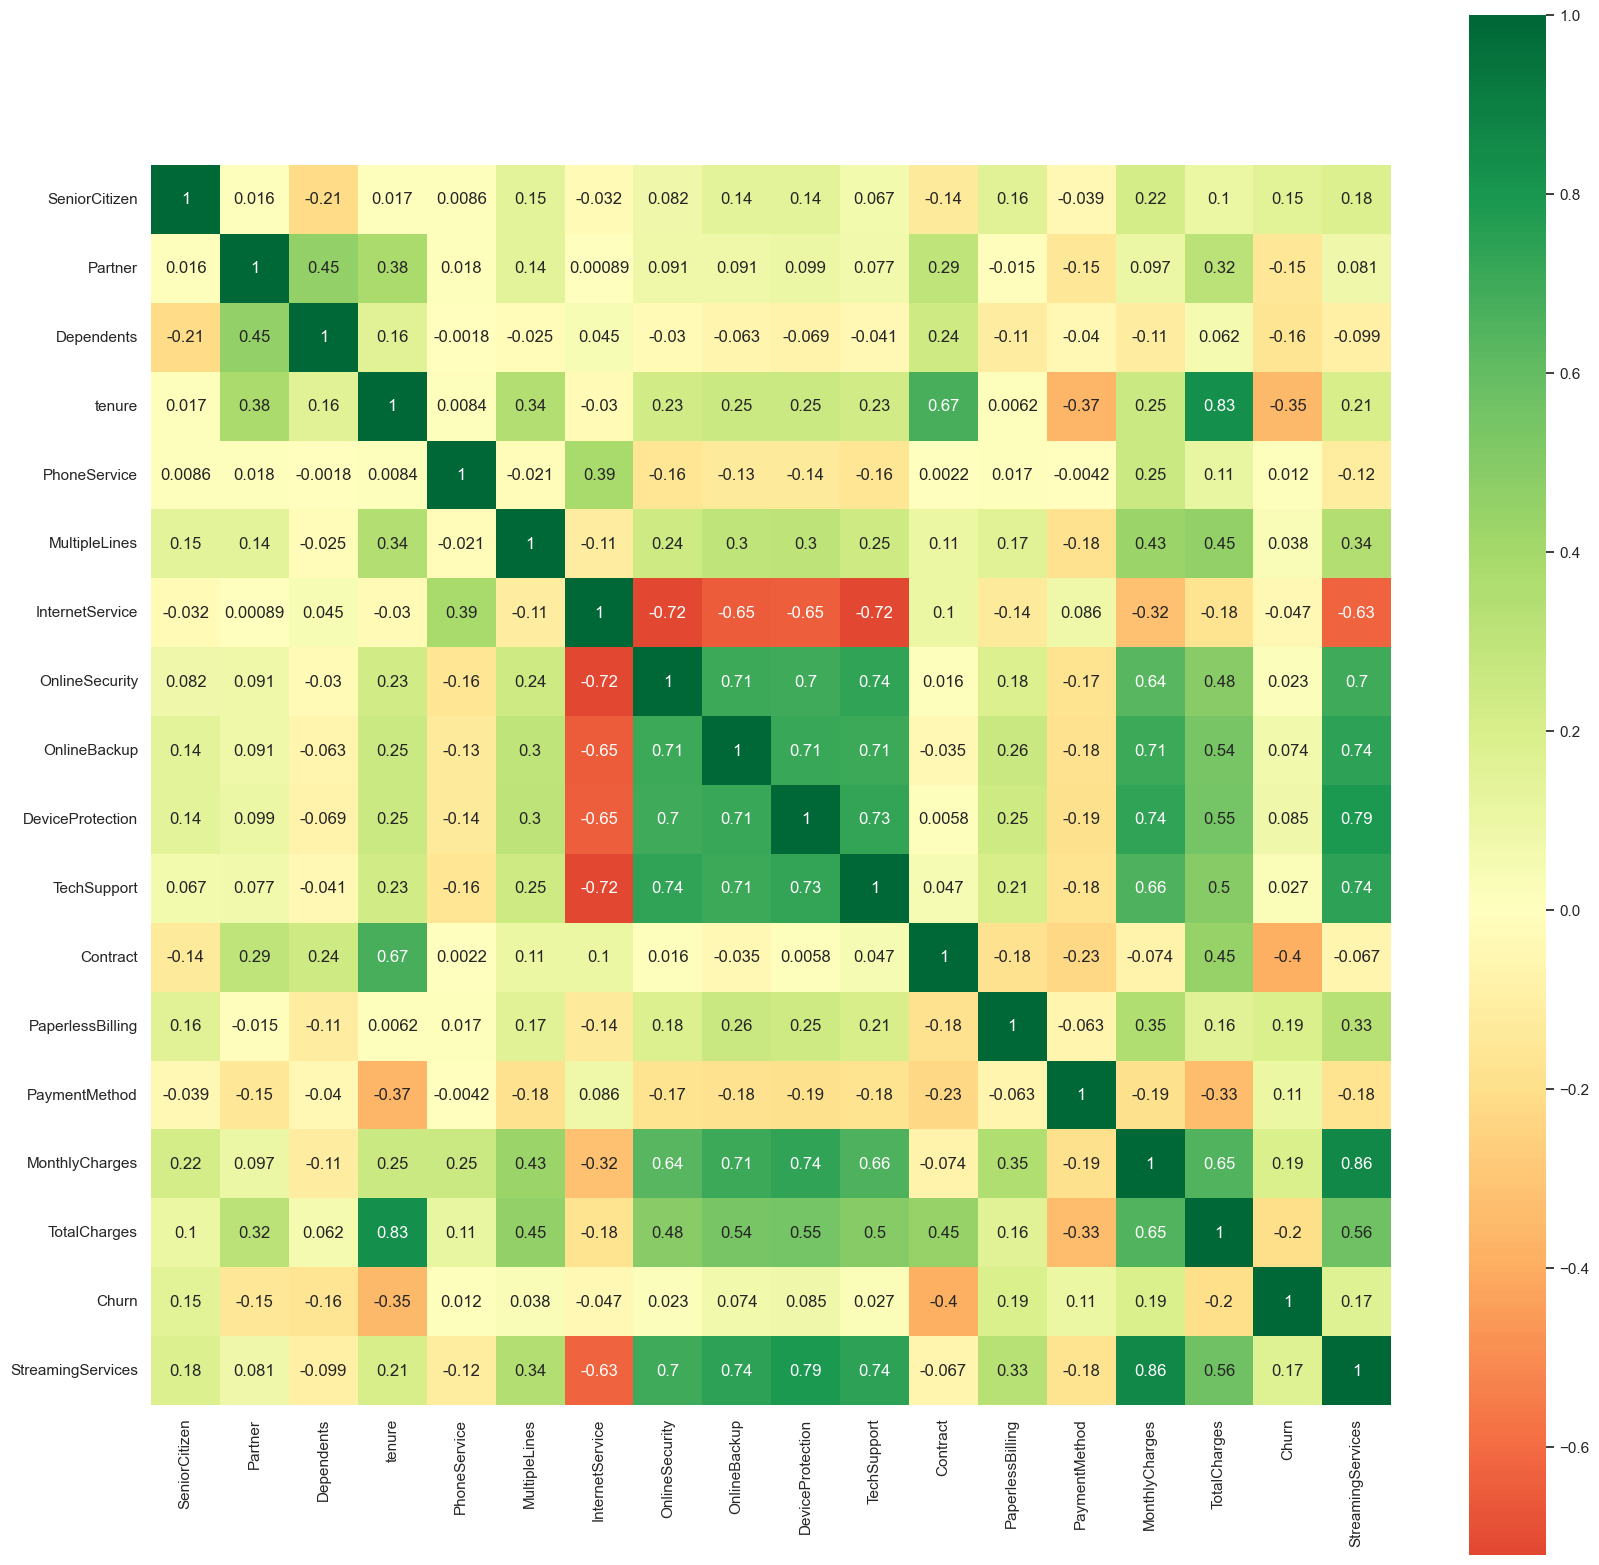

In [350]:
plt.figure(figsize = (20, 20))
# Plot the correlation matrix as a heatmap
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', center=0, square=True)

# Train-Test Split

In [351]:
from sklearn.model_selection import train_test_split

In [352]:
selected_features = [
    'tenure',
    'MonthlyCharges',
    'Contract',
    'InternetService',
    'StreamingServices'
]



In [353]:
X = df[selected_features]
y = df['Churn']

In [354]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [355]:
#Training data size
X_train.shape

(5634, 5)

In [356]:
#Test data Size
X_test.shape

(1409, 5)

# Random Forest

In [357]:
#Will be training using a RandomForest model
from sklearn.ensemble import RandomForestClassifier



rf = RandomForestClassifier(
    n_estimators=100,     # number of trees
    max_depth=10,       # tree depth
    min_samples_split=5,
    random_state=42,
    min_samples_leaf = 5
)
#train model
rf.fit(X_train, y_train)
y_pred_test = rf.predict(X_train)
y_pred = rf.predict(X_test)

## Checking Accuracy metrics for the Random Forest

In [358]:
from sklearn.metrics import accuracy_score, roc_auc_score


In [359]:
train_acc = accuracy_score(y_train, rf.predict(X_train))
test_acc  = accuracy_score(y_test, rf.predict(X_test))

print(f"Training Accuracy: {train_acc}")
print(f"Test Accuracy: {test_acc}")

Training Accuracy: 0.8342208022719205
Test Accuracy: 0.8005677785663591


In [360]:
roc_auc1 = roc_auc_score(y_pred_test, rf.predict_proba(X_train)[:,1])
print("Train ROC AUC:", roc_auc1)
roc_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
print("Test ROC AUC:", roc_auc)

Train ROC AUC: 1.0
Test ROC AUC: 0.8480622522177482


# K-Nearest Neighbor(KNN)

In [361]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=10, weights='uniform')
knn.fit(X_train, y_train)
y_pred_test = knn.predict(X_train)
y_pred = knn.predict(X_test)

## Checking the Accuracy of the KNN model

In [362]:
train_acc = accuracy_score(y_train, knn.predict(X_train))
test_acc  = accuracy_score(y_test, knn.predict(X_test))

print(f"Training Accuracy: {train_acc}")
print(f"Test Accuracy: {test_acc}")

Training Accuracy: 0.8122115725949591
Test Accuracy: 0.7863733144073811


# Naive Bayes

In [363]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_test = nb.predict(X_train)
y_pred = nb.predict(X_test)

## Checking the Accuracy of the Naive Bayes model

In [364]:
train_acc = accuracy_score(y_train, nb.predict(X_train))
test_acc  = accuracy_score(y_test, nb.predict(X_test))

print(f"Training Accuracy: {train_acc}")
print(f"Test Accuracy: {test_acc}")

Training Accuracy: 0.7293219737309194
Test Accuracy: 0.7430801987224982


# Neural Network

In [365]:
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(64,32), activation='relu',solver='adam',alpha=0.001, random_state=42, max_iter=200)
mlp.fit(X_train, y_train)
y_pred_test=mlp.predict(X_train)
y_pred = mlp.predict(X_test)


## Checking the Accuracy of the Neural Network model

In [366]:
train_acc = accuracy_score(y_train, mlp.predict(X_train))
test_acc  = accuracy_score(y_test, mlp.predict(X_test))

print(f"Training Accuracy: {train_acc}")
print(f"Test Accuracy: {test_acc}")

Training Accuracy: 0.7907348242811502
Test Accuracy: 0.7963094393186657


In [367]:
print (X.columns)

Index(['tenure', 'MonthlyCharges', 'Contract', 'InternetService',
       'StreamingServices'],
      dtype='object')


In [368]:
import joblib

In [369]:
#joblib.dump({
 #   "model": rf,
  #  "features": ["tenure", "monthly_charges", "contract", "internet_service", "streaming_services"]
#}, "churn_model.pkl")

In [374]:


sample = np.array([[30, 20, 0, 1, 0]])  # example features

prediction = rf.predict(sample)
print(prediction)

[0.]


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [371]:
proba = rf.predict_proba(sample)
print(proba)

[[0.71395129 0.28604871]]


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
